# Compare notebook 05 populations

This report compares a named experiment with its recorded baseline. Start with the [experiment index](../docs/pilot_experiments.md). **Run All is read-only: it does not train, load models, use the GPU, or rerun simulations.** Use the project `.venv` kernel. Rerun it to refresh results while training continues, then save the notebook to retain its tables and embedded plots.

Choose `EXPERIMENT` below from `configs/pilot_experiments.json`, or override `EXPERIMENT_JOB` to inspect another prepared experiment. Its recorded plan supplies the baseline and training directories. Experiments run separately; this report never starts or resumes them.

The tables and plots use the same recorded metrics as notebook 05: checkpoint selection, test competence, behaviour, skill fractions, common validation reward components, learning curves, clean-win intervals and behaviour scatter. Results appear only when a pilot finishes training and testing; partial learning curves are labelled.

The original test has already informed this experiment, so it is now a **development comparison**. The separate **fresh confirmation** section becomes available after both populations have been evaluated on the predeclared new cases. Neither report changes checkpoints.


In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "bvr_behavior_prediction").is_dir()
)
# Choose a name from the registry. BVR_COMPARISON_JOB also accepts an unregistered job.
registry = json.loads((REPO_ROOT / "configs/pilot_experiments.json").read_text(encoding="utf8"))
EXPERIMENT = os.getenv("BVR_COMPARISON_EXPERIMENT", registry["default_experiment"])
EXPERIMENT_JOB = Path(os.getenv(
    "BVR_COMPARISON_JOB", str(REPO_ROOT / registry["experiments"][EXPERIMENT]["job"])
)).resolve()


def read_json(path):
    # A running process may be updating a manifest at the instant it is read.
    for attempt in range(3):
        try:
            return json.loads(path.read_text(encoding="utf8"))
        except json.JSONDecodeError:
            if attempt == 2:
                raise
            time.sleep(0.1)


def read_metrics(path):
    if not path.exists():
        return pd.DataFrame()
    lines = path.read_text(encoding="utf8").splitlines()
    rows = []
    for index, line in enumerate(lines):
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            if index != len(lines) - 1:
                raise  # Only an incomplete final append is expected during training.
    return pd.DataFrame(rows)


plan = read_json(EXPERIMENT_JOB / "experiment.json")
EXPERIMENT_LABEL = plan.get("experiment_label", "Lower learning rate")
RUNS = {
    "Baseline": Path(plan["baseline"]),
    EXPERIMENT_LABEL: Path(plan["training_output"]),
}
status = read_json(EXPERIMENT_JOB / "status.json")
print(f"Experiment status: {status['status']}")
if "error" in status:
    print(status["error"])
print(plan.get("change_description", f"Learning rate: {plan['baseline_learning_rate']} -> {plan['learning_rate']}"))
if "recovery" in plan:
    recovery = plan["recovery"]
    print("Preserved completed pilots:", ", ".join(recovery["reused_pilots"]))
    print("Train from original seeds:", ", ".join(recovery["restart_from_scratch"]))
    print("The failed attempt is preserved at:", recovery["previous_job"])
print(f"Experiment: {EXPERIMENT_JOB}")
print("This report is a snapshot. Run All again to refresh it.")


Experiment status: training
Only selected-skill log-probabilities and expected parameter entropy changed.
Preserved completed pilots: pilot_001, pilot_002, pilot_003, pilot_004, pilot_005
Train from original seeds: pilot_006, pilot_007, pilot_008, pilot_009, pilot_010
The failed attempt is preserved at: C:\Users\jttur\VSCodeProjects\Trajectory_Classification\artifacts\rl_pilot_experiments\20261009T092543_792046Z_selected_skill_parameters
Experiment: C:\Users\jttur\VSCodeProjects\Trajectory_Classification\artifacts\rl_pilot_experiments\20261009T153646_051001Z_selected_skill_parameters_recovery
This report is a snapshot. Run All again to refresh it.


## Progress and saved reward preferences

The same pilot ID refers to the same sampled reward coefficients in both runs. These are **coefficients**, not cumulative reward contributions. Training returns are comparable between the two versions of a given pilot; they are not a common score across pilots with different preferences.


In [2]:
batches = {
    name: read_json(directory / "pilots.json")
    if (directory / "pilots.json").exists() else {"pilots": []}
    for name, directory in RUNS.items()
}
metrics_by_run = {}
progress_rows, reward_rows, completed_rows = [], [], []
for name, batch in batches.items():
    metrics_by_run[name] = {}
    for pilot in batch["pilots"]:
        pilot_id = pilot["pilot_id"]
        directory = RUNS[name] / pilot.get("output_dir", pilot_id)
        metrics = read_metrics(directory / "training_metrics.jsonl")
        metrics_by_run[name][pilot_id] = metrics
        progress_rows.append({
            "run": name, "pilot_id": pilot_id, "status": pilot["status"],
            "epochs_finished": int(metrics["epoch"].max()) if not metrics.empty else 0,
            "epochs_planned": plan["epochs_per_pilot"],
        })
        reward_rows.append({
            "run": name, "pilot_id": pilot_id, "seed": pilot["seed"],
            **pilot["reward"]["parameters"]["weights"],
        })
        if pilot["status"] == "completed":
            completed_rows.append({"run": name, **pilot})

progress = pd.DataFrame(progress_rows)
display(progress)
display(pd.DataFrame(reward_rows).set_index(["run", "pilot_id"]))
print("Completed pilots:", {
    name: sum(p["status"] == "completed" for p in batch["pilots"])
    for name, batch in batches.items()
})


,run,pilot_id,status,epochs_finished,epochs_planned
0,Baseline,pilot_001,completed,150,150
1,Baseline,pilot_002,completed,150,150
2,Baseline,pilot_003,completed,150,150
3,Baseline,pilot_004,completed,150,150
4,Baseline,pilot_005,completed,150,150
5,Baseline,pilot_006,completed,150,150
6,Baseline,pilot_007,completed,150,150
7,Baseline,pilot_008,completed,150,150
8,Baseline,pilot_009,completed,150,150
9,Baseline,pilot_010,completed,150,150


seed     crashed   shot_down  \
run                       pilot_id                                  
Baseline                  pilot_001     7 -333.906593 -384.168234   
                          pilot_002     7 -430.782955 -382.442109   
                          pilot_003     7 -366.812282 -440.427412   
                          pilot_004     7 -333.242475 -420.804194   
                          pilot_005     7 -401.126196 -394.431044   
                          pilot_006     7 -384.427212 -325.098271   
                          pilot_007     7 -347.625674 -429.037127   
                          pilot_008     7 -381.162634 -364.688821   
                          pilot_009     7 -354.792252 -366.963090   
                          pilot_010     7 -321.989539 -414.909077   
Selected-skill parameters pilot_001     7 -333.906593 -384.168234   
                          pilot_002     7 -430.782955 -382.442109   
                          pilot_003     7 -366.812282 -440.427412   
                          pilot_004     7 -333.242475 -420.804194   
                          pilot_005     7 -401.126196 -394.431044   
                          pilot_006     7 -384.427212 -325.098271   
                          pilot_007     7 -347.625674 -429.037127   
                          pilot_008     7 -381.162634 -364.688821   
                          pilot_009     7 -354.792252 -366.963090   
                          pilot_010     7 -321.989539 -414.909077   

                                     ground_clearance  target_lock_acquired  \
run                       pilot_id                                            
Baseline                  pilot_001              0.02              1.394736   
                          pilot_002              0.02              1.853530   
                          pilot_003              0.02              1.263329   
                          pilot_004              0.02              0.087608   
                          pilot_005              0.02              0.378943   
                          pilot_006              0.02              0.624733   
                          pilot_007              0.02              0.014725   
                          pilot_008              0.02              0.229060   
                          pilot_009              0.02              0.607900   
                          pilot_010              0.02              0.562768   
Selected-skill parameters pilot_001              0.02              1.394736   
                          pilot_002              0.02              1.853530   
                          pilot_003              0.02              1.263329   
                          pilot_004              0.02              0.087608   
                          pilot_005              0.02              0.378943   
                          pilot_006              0.02              0.624733   
                          pilot_007              0.02              0.014725   
                          pilot_008              0.02              0.229060   
                          pilot_009              0.02              0.607900   
                          pilot_010              0.02              0.562768   

                                     fired_with_lock  \
run                       pilot_id                     
Baseline                  pilot_001         0.188355   
                          pilot_002         1.287730   
                          pilot_003         1.516175   
                          pilot_004         0.308579   
                          pilot_005         0.259843   
                          pilot_006         1.664520   
                          pilot_007         1.573849   
                          pilot_008         1.336806   
                          pilot_009         0.061636   
                          pilot_010         0.587188   
Selected-skill parameters pilot_001         0.188355   
                          pilot_002         1.28773

Completed pilots: {'Baseline': 10, 'Selected-skill parameters': 6}


## Checkpoint selection and original test competence

These reproduce notebook 05's first two result tables, with a run column. **Selection return** uses each pilot's own reward. **Benchmark return** uses the common reward on validation scenarios. The second table reports the separate original test cases, now used for development comparison.

A clean win means a confirmed missile elimination while surviving. The shared outcome score is +100 for a clean win, 0 for survival without a confirmed elimination, -50 for mutual destruction and -100 for own loss with the opponent alive. Confidence intervals describe scenario uncertainty, not variation between repeated training seeds. Missing results mean pending, not zero.


In [3]:
summary = pd.DataFrame(completed_rows)
test_summary = pd.DataFrame([
    {"run": pilot["run"], "pilot_id": pilot["pilot_id"], **pilot["test"]}
    for pilot in completed_rows if "test" in pilot
])
COMPETENCE_COLUMNS = [
    "run", "pilot_id", "scenarios", "clean_win_rate", "clean_win_ci95",
    "mutual_destruction_rate", "survival_rate", "elimination_rate", "outcome_score",
]
BEHAVIOUR_COLUMNS = [
    "run", "pilot_id", "mean_missiles_launched", "mean_missiles_avoided",
    "mean_threatened_seconds", "mean_duration_seconds",
]


def show_competence(frame):
    if frame.empty:
        print("No completed evaluations yet.")
    else:
        display(frame[COMPETENCE_COLUMNS].sort_values(
            ["run", "clean_win_rate", "outcome_score"], ascending=[True, False, False]
        ))


if not summary.empty:
    display(summary[[
        "run", "pilot_id", "selection_return", "benchmark_return", "checkpoint"
    ]])
show_competence(test_summary)


,run,pilot_id,selection_return,benchmark_return,checkpoint
0,Baseline,pilot_001,32.812303,148.6384,pilot_001/best_model.pt
1,Baseline,pilot_002,90.515145,227.4080,pilot_002/best_model.pt
2,Baseline,pilot_003,45.134890,221.8916,pilot_003/best_model.pt
3,Baseline,pilot_004,66.166640,214.4524,pilot_004/best_model.pt
4,Baseline,pilot_005,6.780261,157.4232,pilot_005/best_model.pt
5,Baseline,pilot_006,140.657888,243.2404,pilot_006/best_model.pt
6,Baseline,pilot_007,56.141263,208.3896,pilot_007/best_model.pt
7,Baseline,pilot_008,65.026865,203.1556,pilot_008/best_model.pt
8,Baseline,pilot_009,62.346132,204.1024,pilot_009/best_model.pt
9,Baseline,pilot_010,89.341866,234.3820,pilot_010/best_model.pt


,run,pilot_id,scenarios,clean_win_rate,clean_win_ci95,mutual_destruction_rate,survival_rate,elimination_rate,outcome_score
9,Baseline,pilot_010,100,0.52,"[0.4231657776522397, 0.615354482419481]",0.24,0.67,0.76,31.0
5,Baseline,pilot_006,100,0.41,"[0.3186731302113651, 0.5079856994658921]",0.26,0.69,0.67,23.0
2,Baseline,pilot_003,100,0.39,"[0.3001687400639441, 0.4879698295415926]",0.28,0.65,0.67,18.0
6,Baseline,pilot_007,100,0.39,"[0.3001687400639441, 0.4879698295415926]",0.20,0.68,0.59,17.0
3,Baseline,pilot_004,100,0.38,"[0.29097599252478734, 0.47790244704488916]",0.23,0.72,0.61,21.5
8,Baseline,pilot_009,100,0.37,"[0.28182360534324524, 0.4677947041905709]",0.27,0.65,0.64,15.5
1,Baseline,pilot_002,100,0.32,"[0.23669147324999093, 0.41662618610452384]",0.37,0.58,0.69,8.5
7,Baseline,pilot_008,100,0.31,"[0.22779697212376038, 0.40626055719489407]",0.25,0.68,0.56,11.5
4,Baseline,pilot_005,100,0.30,"[0.2189488529493276, 0.3958485463334666]",0.18,0.65,0.48,4.0
0,Baseline,pilot_001,100,0.29,"[0.2101483574912227, 0.3853889117557111]",0.12,0.68,0.41,3.0


## Original test behaviour and common validation components

Missile use, threat exposure and skill fractions describe observed behaviour; they are not measures of competence by themselves. The final table contains **mean cumulative points per flight under the common validation reward**, exactly as in notebook 05. Each row sums to that pilot's validation benchmark return. These values are not reward coefficients.


In [4]:
def show_behaviour(frame):
    if frame.empty:
        print("No completed behaviour evaluations yet.")
        return
    display(frame[BEHAVIOUR_COLUMNS])
    skills = pd.DataFrame([
        {"run": row["run"], "pilot_id": row["pilot_id"], **row["skill_decision_fractions"]}
        for _, row in frame.iterrows()
    ]).set_index(["run", "pilot_id"]).fillna(0.0)
    display(skills)


show_behaviour(test_summary)
if completed_rows:
    print("Common validation reward components: mean points per flight")
    display(pd.DataFrame([
        {"run": pilot["run"], "pilot_id": pilot["pilot_id"],
         **pilot["benchmark_component_means"]}
        for pilot in completed_rows
    ]).set_index(["run", "pilot_id"]))


,run,pilot_id,mean_missiles_launched,mean_missiles_avoided,mean_threatened_seconds,mean_duration_seconds
0,Baseline,pilot_001,0.58,3.35,68.898,85.412
1,Baseline,pilot_002,1.55,2.97,65.636,78.352
2,Baseline,pilot_003,1.07,3.28,70.938,82.520
3,Baseline,pilot_004,1.55,3.54,73.207,85.774
4,Baseline,pilot_005,0.99,3.09,68.420,82.572
5,Baseline,pilot_006,1.57,3.41,71.826,83.179
6,Baseline,pilot_007,1.13,3.41,70.708,82.272
7,Baseline,pilot_008,1.25,3.10,71.544,85.015
8,Baseline,pilot_009,1.12,3.08,70.282,82.435
9,Baseline,pilot_010,1.12,3.17,68.973,79.584


abort_support  beam_missile_left  \
run                       pilot_id                                      
Baseline                  pilot_001       0.000934           0.090697   
                          pilot_002       0.000508           0.021988   
                          pilot_003       0.015214           0.041174   
                          pilot_004       0.001860           0.011744   
                          pilot_005       0.013401           0.040565   
                          pilot_006       0.000000           0.014977   
                          pilot_007       0.003875           0.003632   
                          pilot_008       0.000000           0.004575   
                          pilot_009       0.062840           0.047372   
                          pilot_010       0.013628           0.027632   
Selected-skill parameters pilot_001       0.000780           0.001300   
                          pilot_002       0.070640           0.000000   
                          pilot_003       0.000118           0.002720   
                          pilot_004       0.092960           0.000000   
                          pilot_005       0.000000           0.000000   
                          pilot_006       0.001366           0.001117   

                                     beam_missile_right  beam_target_left  \
run                       pilot_id                                          
Baseline                  pilot_001            0.010039          0.000584   
                          pilot_002            0.009278          0.000000   
                          pilot_003            0.011591          0.000000   
                          pilot_004            0.013023          0.012558   
                          pilot_005            0.005191          0.000724   
                          pilot_006            0.026719          0.007429   
                          pilot_007            0.004601          0.000000   
                          pilot_008            0.004810          0.000000   
                          pilot_009            0.004230          0.000242   
                          pilot_010            0.012378          0.000625   
Selected-skill parameters pilot_001            0.004811          0.071382   
                          pilot_002            0.006292          0.035498   
                          pilot_003            0.006386          0.007923   
                          pilot_004            0.004936          0.067576   
                          pilot_005            0.006920          0.020388   
                          pilot_006            0.000497          0.088641   

                                     beam_target_right  climb_to_altitude  \
run                       pilot_id                                          
Baseline                  pilot_001           0.001051           0.222949   
                          pilot_002           0.013091           0.266650   
                          pilot_003           0.012678           0.101546   
                          pilot_004           0.001163           0.000116   
                          pilot_005           0.034287           0.041531   
                          pilot_006           0.011862           0.026480   
                          pilot_007           0.001332           0.095290   
                          pilot_008           0.014664           0.159667   
                          pilot_009           0.003867           0.015831   
                          pilot_010           0.004251           0.003751   
Selected-skill parameters pilot_001           0.017293           0.000000   
                          pilot_002           0.096047           0.000000   
                          pilot_003           0.031220           0.000000   
                          pilot_004           0.039018           0.000000   
                          pilot_005           0.121216           0.002224   
                          

Common validation reward components: mean points per flight


crashed  fired_with_lock  \
run                       pilot_id                              
Baseline                  pilot_001      0.0             5.76   
                          pilot_002      0.0            16.64   
                          pilot_003      0.0            11.36   
                          pilot_004      0.0            16.80   
                          pilot_005      0.0             8.96   
                          pilot_006      0.0            17.60   
                          pilot_007      0.0            12.16   
                          pilot_008      0.0            13.12   
                          pilot_009      0.0            10.72   
                          pilot_010      0.0            10.56   
Selected-skill parameters pilot_001      0.0            15.52   
                          pilot_002      0.0            17.12   
                          pilot_003      0.0            11.20   
                          pilot_004      0.0            11.52   
                          pilot_005      0.0            11.68   
                          pilot_006      0.0            11.04   

                                     fired_without_lock  ground_clearance  \
run                       pilot_id                                          
Baseline                  pilot_001                 0.0            1.4784   
                          pilot_002                 0.0            1.3680   
                          pilot_003                 0.0            1.4116   
                          pilot_004                 0.0            1.4524   
                          pilot_005                 0.0            1.4232   
                          pilot_006                 0.0            1.4804   
                          pilot_007                 0.0            1.4296   
                          pilot_008                 0.0            1.4356   
                          pilot_009                 0.0            1.4224   
                          pilot_010                 0.0            1.4220   
Selected-skill parameters pilot_001                 0.0            1.4028   
                          pilot_002                 0.0            1.4784   
                          pilot_003                 0.0            1.4476   
                          pilot_004                 0.0            1.4400   
                          pilot_005                 0.0            1.4668   
                          pilot_006                 0.0            1.4612   

                                     missile_avoided  opponent_destroyed  \
run                       pilot_id                                         
Baseline                  pilot_001             59.6               140.0   
                          pilot_002             53.6               220.0   
                          pilot_003             53.2               220.0   
                          pilot_004             56.4               195.0   
                          pilot_005             51.2               160.0   
                          pilot_006             61.2               215.0   
                          pilot_007             58.0               195.0   
                          pilot_008             54.8               195.0   
                          pilot_009             51.2               205.0   
                          pilot_010             55.6               225.0   
Selected-skill parameters pilot_001             58.0               210.0   
                          pilot_002             64.0               225.0   
                          pilot_003             61.2               210.0   
                          pilot_004             60.4               215.0   
                          pilot_005             58.8               205.0   
                          pilot_006             61.6               200.0   

                                     shot_down  target_locked  
run                       pilot_id            

## Learning curves, including pilots still training

Each row compares matching reward preferences. Colours distinguish runs; line styles distinguish training, validation and best validation return. The right panel shows the actor and critic losses in their learning units. Partial curves are labelled with their last completed epoch. Lower loss alone does not establish better combat performance.

For selected-skill experiments, policy loss, entropy and KL use a different action probability definition. Their absolute values are not directly comparable with the unmasked baseline. Value loss retains its definition, but each policy collects different flights. Judge improvement by the matched outcome evaluations.


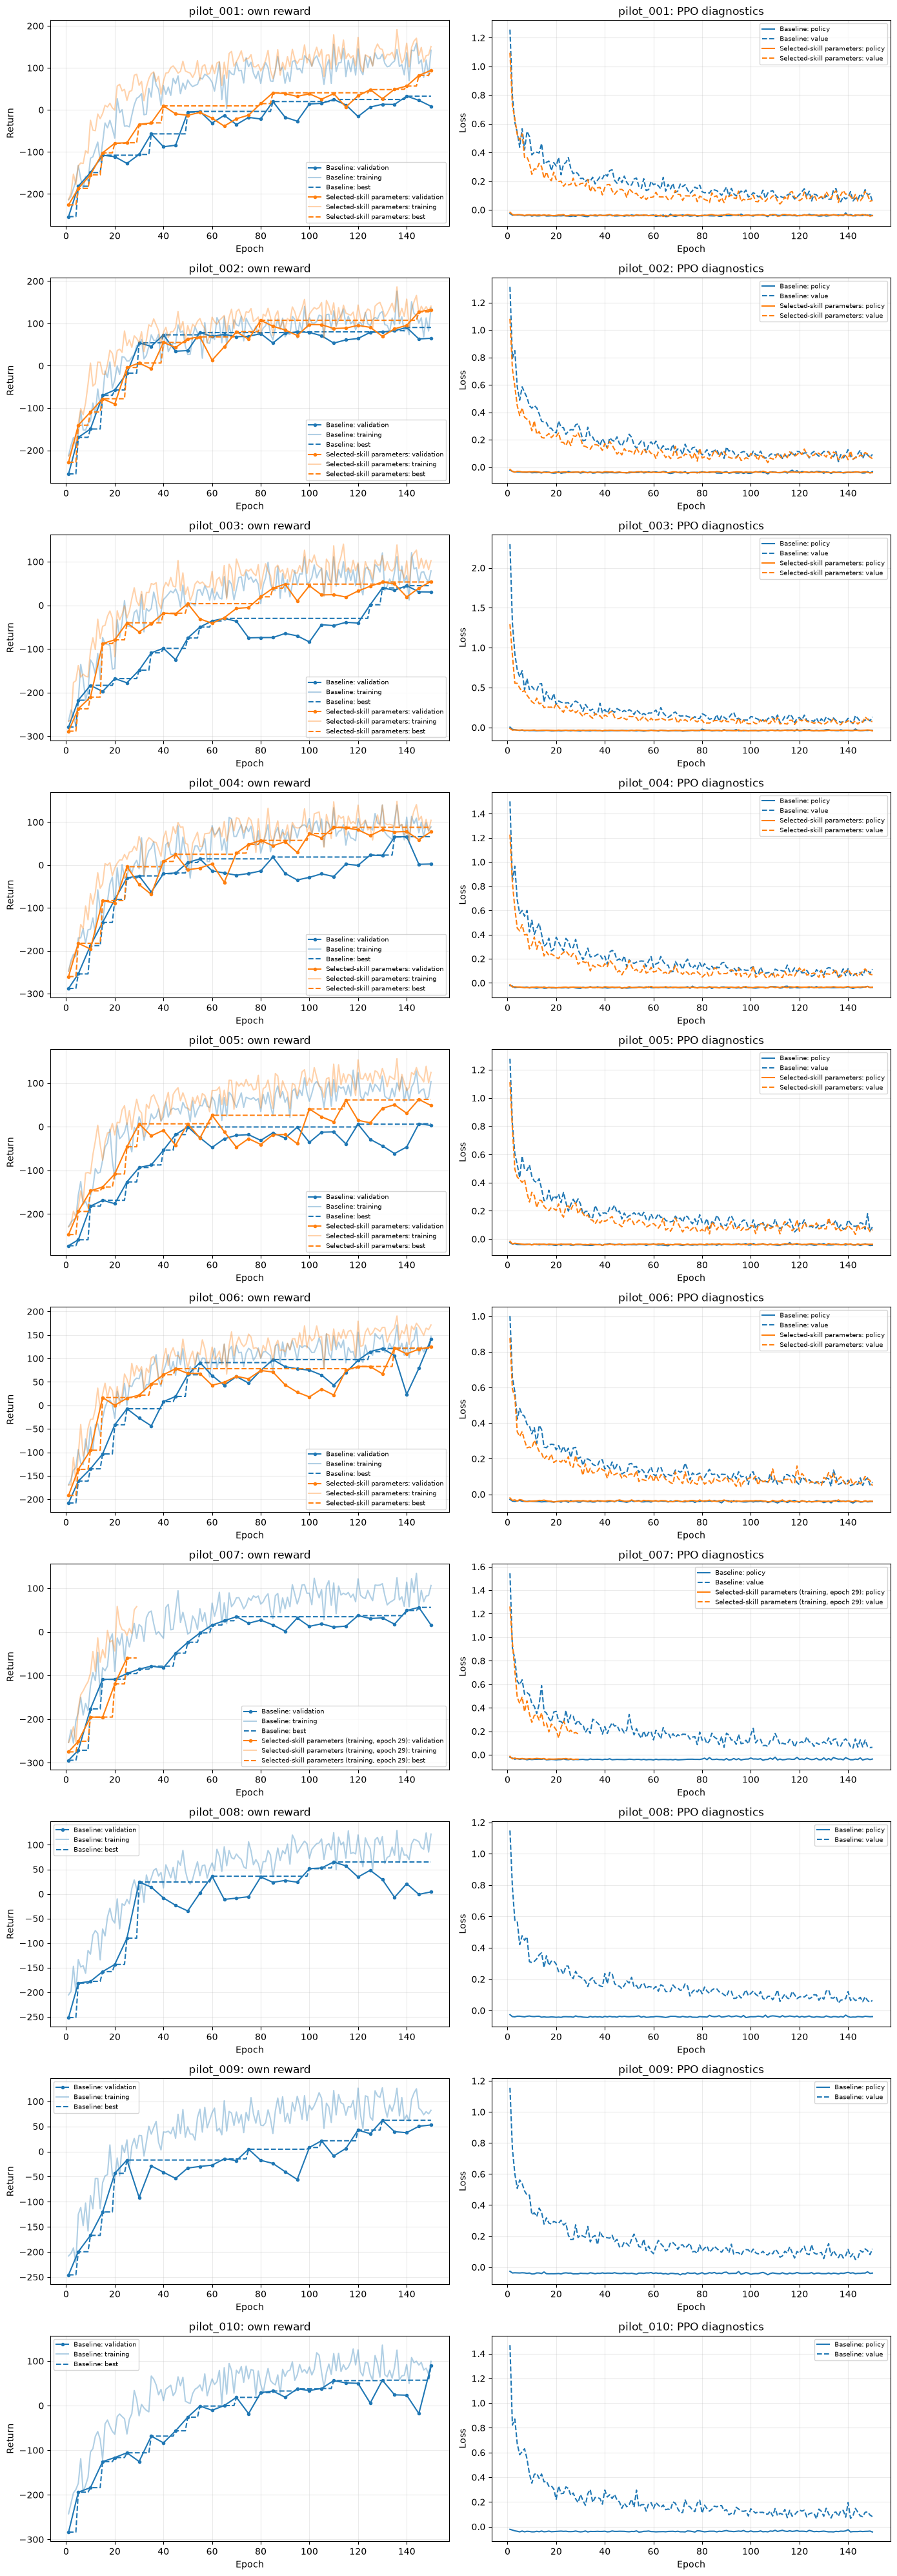

In [5]:
COLOURS = {"Baseline": "tab:blue", EXPERIMENT_LABEL: "tab:orange"}
pilot_ids = sorted({
    pilot_id for metrics in metrics_by_run.values()
    for pilot_id, frame in metrics.items() if not frame.empty
})
if pilot_ids:
    figure, axes = plt.subplots(len(pilot_ids), 2, figsize=(14, 4 * len(pilot_ids)), squeeze=False)
    for row, pilot_id in enumerate(pilot_ids):
        for name, records in metrics_by_run.items():
            metrics = records.get(pilot_id, pd.DataFrame())
            if metrics.empty:
                continue
            pilot_status = next(p["status"] for p in batches[name]["pilots"] if p["pilot_id"] == pilot_id)
            label = name
            if pilot_status != "completed":
                label += f" ({pilot_status}, epoch {int(metrics['epoch'].max())})"
            evaluated = metrics[metrics["evaluation_performed"] == 1]
            colour = COLOURS[name]
            axes[row, 0].plot(evaluated["epoch"], evaluated["mean_return"],
                              marker=".", color=colour, label=f"{label}: validation")
            axes[row, 0].plot(metrics["epoch"], metrics["training_mean_return"],
                              alpha=0.35, color=colour, label=f"{label}: training")
            axes[row, 0].plot(metrics["epoch"], metrics["best_return"],
                              linestyle="--", color=colour, label=f"{label}: best")
            if {"policy_loss", "value_loss"}.issubset(metrics.columns):
                axes[row, 1].plot(metrics["epoch"], metrics["policy_loss"],
                                  color=colour, label=f"{label}: policy")
                axes[row, 1].plot(metrics["epoch"], metrics["value_loss"],
                                  linestyle="--", color=colour, label=f"{label}: value")
            else:
                axes[row, 1].plot(metrics["epoch"], metrics["loss"], color=colour, label=label)
        axes[row, 0].set(title=f"{pilot_id}: own reward", xlabel="Epoch", ylabel="Return")
        axes[row, 1].set(title=f"{pilot_id}: PPO diagnostics", xlabel="Epoch", ylabel="Loss")
        for axis in axes[row]:
            axis.grid(alpha=0.25)
            axis.legend(fontsize=7)
    figure.tight_layout()
    plt.show()
else:
    print("No recorded epochs yet.")


## Original test plots

These show the same clean-win intervals and behaviour scatter as notebook 05, with both runs on the same axes. A missing bar is a pending result, not a zero clean-win rate. The Wilson intervals are per pilot and run; use the paired comparison below to assess changes on matching scenarios.


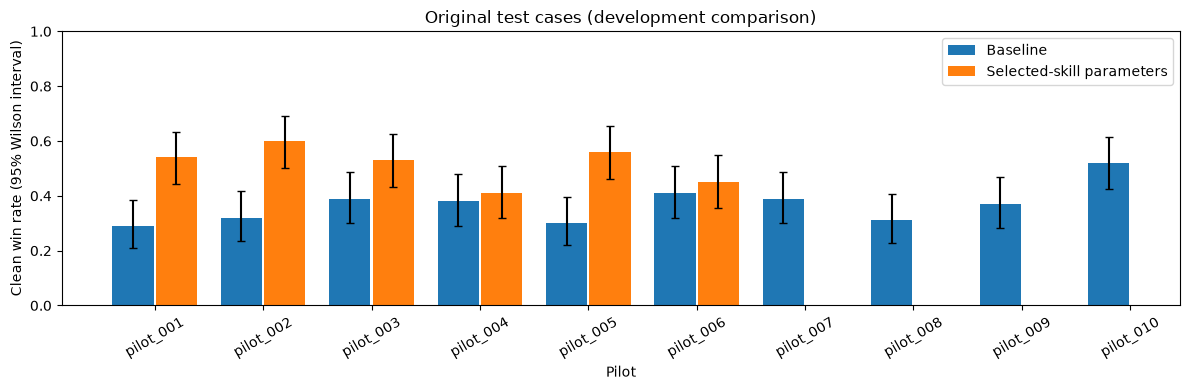

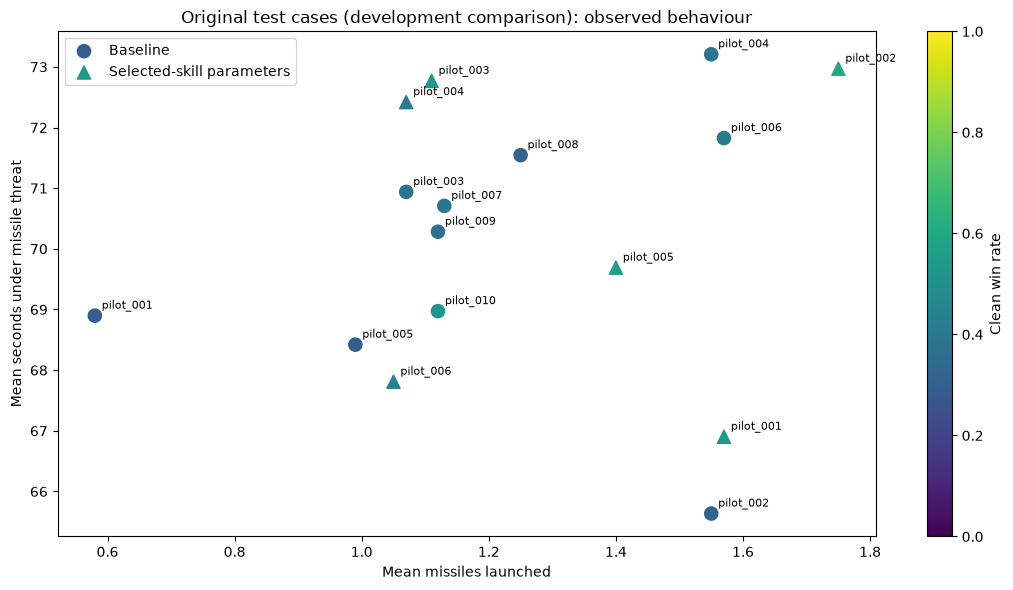

In [6]:
def plot_evaluation(frame, title):
    if frame.empty:
        print(f"{title}: no completed evaluations yet.")
        return
    pilot_ids = sorted(frame["pilot_id"].unique())
    positions = np.arange(len(pilot_ids))
    figure, axis = plt.subplots(figsize=(12, 4))
    for offset, (name, colour) in zip((-0.2, 0.2), COLOURS.items()):
        data = frame[frame["run"] == name]
        if data.empty:
            continue
        x = np.asarray([pilot_ids.index(pilot_id) for pilot_id in data["pilot_id"]])
        rate = data["clean_win_rate"].to_numpy()
        bounds = np.asarray(data["clean_win_ci95"].tolist())
        errors = np.maximum(0, np.vstack((rate - bounds[:, 0], bounds[:, 1] - rate)))
        axis.bar(x + offset, rate, width=0.38, yerr=errors, capsize=3, color=colour, label=name)
    axis.set(xticks=positions, xticklabels=pilot_ids, ylim=(0, 1), xlabel="Pilot",
             ylabel="Clean win rate (95% Wilson interval)", title=title)
    axis.tick_params(axis="x", labelrotation=30)
    axis.legend()
    figure.tight_layout()
    plt.show()

    figure, axis = plt.subplots(figsize=(11, 6))
    points = None
    for name, marker in zip(COLOURS, ("o", "^")):
        data = frame[frame["run"] == name].dropna(
            subset=["mean_missiles_launched", "mean_threatened_seconds"]
        )
        if data.empty:
            continue
        points = axis.scatter(
            data["mean_missiles_launched"], data["mean_threatened_seconds"],
            c=data["clean_win_rate"], vmin=0, vmax=1, s=90, cmap="viridis",
            marker=marker, label=name,
        )
        for _, pilot in data.iterrows():
            axis.annotate(pilot["pilot_id"],
                          (pilot["mean_missiles_launched"], pilot["mean_threatened_seconds"]),
                          xytext=(5, 5), textcoords="offset points", fontsize=8)
    axis.set(title=f"{title}: observed behaviour",
             xlabel="Mean missiles launched", ylabel="Mean seconds under missile threat")
    if points is not None:
        figure.colorbar(points, ax=axis, label="Clean win rate")
        axis.legend()
    figure.tight_layout()
    plt.show()


plot_evaluation(test_summary, "Original test cases (development comparison)")


## Fresh confirmation: the same evaluation tables and plots

After training, the runner evaluates **both populations** on the predeclared fresh scenarios. This section reads those results as they arrive. It uses the same outcome definitions, behaviour measurements and plots as above. Until both populations finish, these are partial results; the final population comparison appears in the next section.


In [7]:
confirmation_rows = []
for population, name in (("baseline", "Baseline"), ("experiment", EXPERIMENT_LABEL)):
    for path in sorted((EXPERIMENT_JOB / "confirmation" / population).glob("*/evaluation.json")):
        evaluation = read_json(path)
        confirmation_rows.append({
            "run": name, "pilot_id": path.parent.name, **evaluation["summary"]
        })
confirmation_summary = pd.DataFrame(confirmation_rows)
print(f"Predeclared suite: {plan['confirmation']}")
show_competence(confirmation_summary)
show_behaviour(confirmation_summary)
plot_evaluation(confirmation_summary, "Fresh confirmation")


Predeclared suite: {'seed': 620000, 'scenarios': 100}
No completed evaluations yet.
No completed behaviour evaluations yet.
Fresh confirmation: no completed evaluations yet.


## Matched differences and overall result

The runner writes this comparison only after the relevant suite is complete for the whole population. The primary measure is the mean clean-win rate over all matching reward profiles, not the best pilot. Gained/lost wins count identical cases whose clean-win outcome changed.

The paired bootstrap resamples scenarios jointly across pilots; its interval measures scenario uncertainty. One training seed does not establish a robust improvement. Judge the fresh confirmation alongside survival and mutual destruction; do not select a checkpoint using it.


In [8]:
comparison_path = EXPERIMENT_JOB / "comparison.json"
if comparison_path.exists():
    comparison = read_json(comparison_path)
    aggregate_rows = []
    for suite, title in (
        ("existing_test", "Original test (development)"),
        ("fresh_confirmation", "Fresh confirmation"),
    ):
        if suite not in comparison:
            continue
        values = comparison[suite]
        display(Markdown(f"**{title}: paired changes**"))
        display(pd.DataFrame(values["pilots"]))
        aggregate_rows.append({
            "suite": title,
            "baseline_mean_clean_win_rate": values["baseline_mean_clean_win_rate"],
            "experiment_mean_clean_win_rate": values["experiment_mean_clean_win_rate"],
            "change_percentage_points": values["difference_percentage_points"],
            "paired_change_ci95_percentage_points":
                values["paired_scenario_bootstrap_ci95_percentage_points"],
        })
    display(pd.DataFrame(aggregate_rows))
    print(f"Report status: {comparison['status']}")
    print(f"Standalone report: {EXPERIMENT_JOB / 'comparison.html'}")
else:
    print("The full-population comparison will appear after all pilots finish training and testing.")
print("Save this notebook after refreshing to retain the displayed tables and embedded figures.")


The full-population comparison will appear after all pilots finish training and testing.
Save this notebook after refreshing to retain the displayed tables and embedded figures.
